## Required Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder , StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

# Task 1 : Data Loading & Exploratory Data Analysis

## Load Dataset

In [33]:
original_data = pd.read_csv('../Dataset/Mall_Customers.csv')

df = original_data.copy()

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Basic Info.

In [34]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [35]:
df.shape

(200, 5)

## Dropping Unnecessary Features

In [36]:
df = df.drop( columns = ["CustomerID"])

## Renaming Column / Feature

In [37]:
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

print(df.columns)

Index(['Gender', 'Age', 'Annual_Income', 'Spending_Score'], dtype='object')


## Encoding 

In [38]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [39]:
print(df.head())

   Gender  Age  Annual_Income  Spending_Score
0       1   19             15              39
1       1   21             15              81
2       0   20             16               6
3       0   23             16              77
4       0   31             17              40


## Univariate Distribution

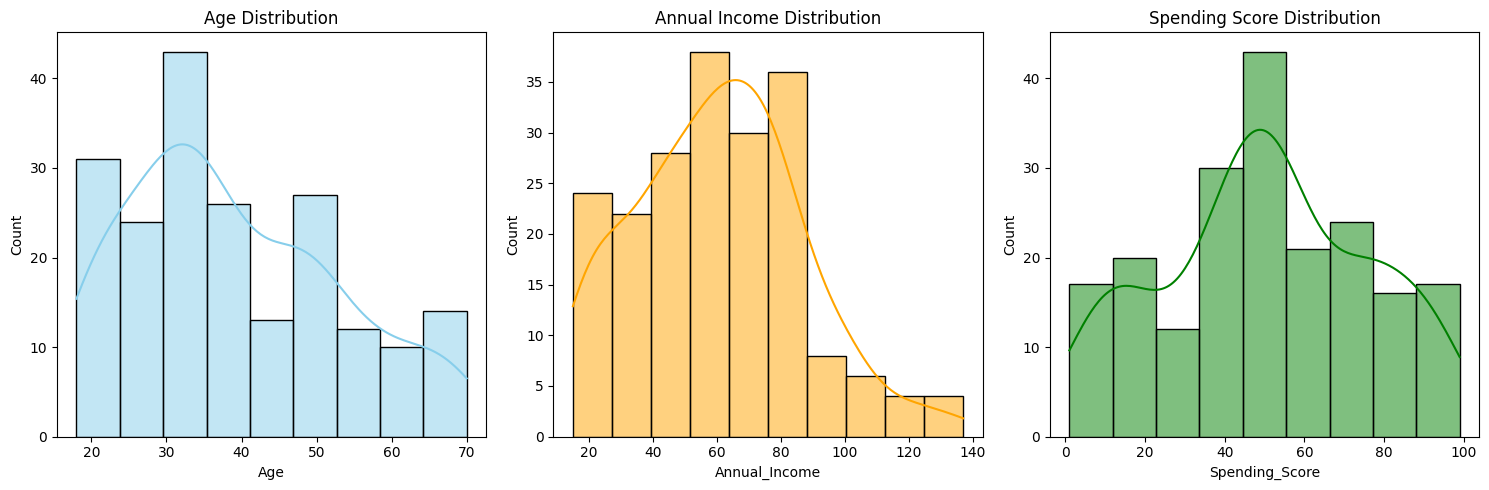

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Age'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual_Income'], kde=True, color='orange', ax=axes[1])
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending_Score'], kde=True, color='green', ax=axes[2])
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

## Correlation Heatmap

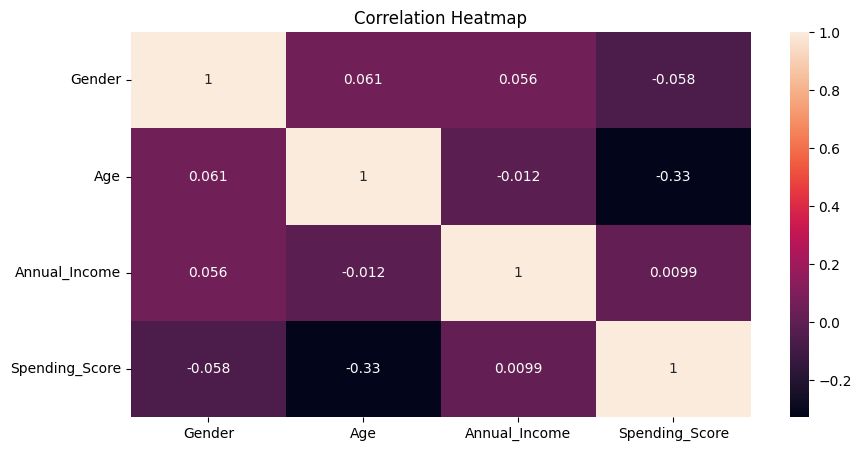

In [41]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### EDA Observation

- Annual_Income and Spending_Score provide the clearest visual separation between different customer groups.
- Annual_Income vs Spending_Score is a good choice because it combines customers' purchasing capacity with their spending behavior.
- These two features can help identify groups such as high-income/high-spending, high-income/low-spending, low-income/high-spending, and low-income/low-spending customers.

# Task 2 : Feature Scaling & Feature Selection

In [42]:
scaler = StandardScaler()

df_scaled = df.copy()

features = ['Age', 'Annual_Income', 'Spending_Score']

df_scaled[features] = scaler.fit_transform(df[features])

In [43]:
df_2f = df_scaled[['Annual_Income', 'Spending_Score']]

### Feature Selection for Clustering

- The primary clustering tasks will use df_2f, which contains Annual_Income and Spending_Score.
- These two features produce clearly separable clusters and allow direct 2D scatter visualisation without using PCA.
- Using all 4 features, including Age and Gender, is also valid.
- The performance of clustering using all 4 features will be tested later in Task 6 (Extension).
- For the primary tasks, df_2f is used for better visual clarity.

### Why Do We Use StandardScaler?

- Clustering algorithms such as K-Means and DBSCAN use distances to determine how similar or different data points are.
- If features have different scales, the feature with larger values can have a greater influence on the distance calculation.
- StandardScaler puts the selected features on a similar scale by transforming them to have a mean of 0 and a standard deviation of 1.
- This prevents one feature from having an unfairly large influence on the clustering results.
- Therefore, scaling helps K-Means and DBSCAN form clusters based on the actual patterns in the data rather than differences in feature magnitude.

# Task 3 : K-Means Clustering

## Elbow Method

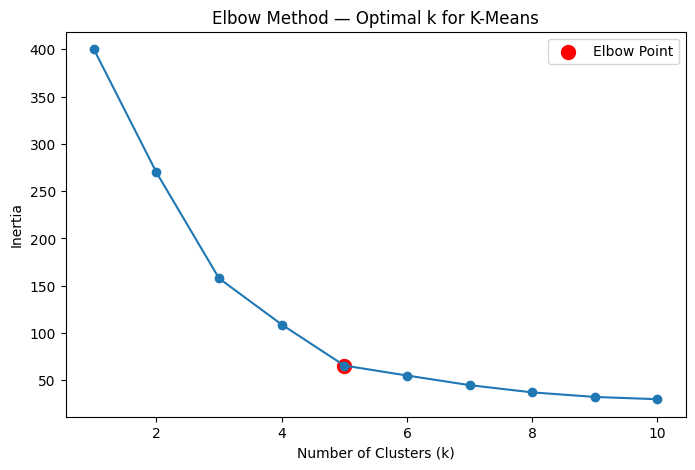

In [44]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_2f)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.scatter(5, inertia[4], color='red', s=100, label='Elbow Point')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k for K-Means')
plt.legend()
plt.show()

## Silhouette Score

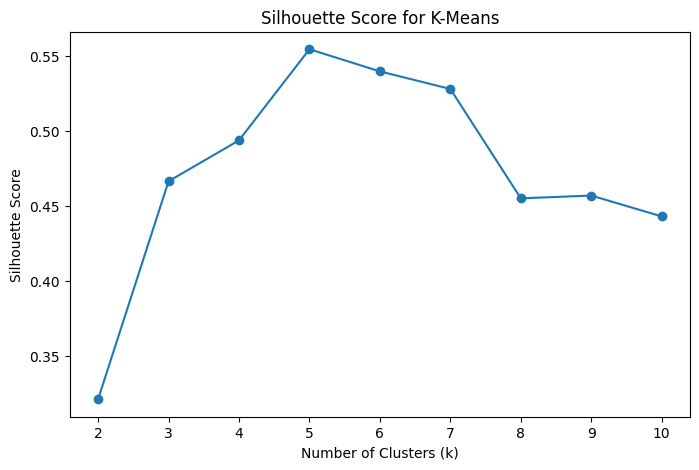

Best k based on Silhouette Score: 5
Highest Silhouette Score: 0.5546571631111091


In [45]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_2f)
    score = silhouette_score(df_2f, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means')
plt.show()

best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print("Best k based on Silhouette Score:", best_k)
print("Highest Silhouette Score:", max(silhouette_scores))

### Elbow Method vs Silhouette Score

- The Elbow Method indicated that k = 5 is a suitable number of clusters.
- The Silhouette Score also reached its highest value at k = 5.
- Since both methods agree, there is consistent evidence that 5 clusters provide a good representation of the customer data.
- The agreement between the two methods means there is no discrepancy to resolve between the Elbow and Silhouette approaches.
- We will use k = 5 for the K-Means clustering task.

## Fit final K-Means model

In [46]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['KMeans_Cluster'] = kmeans.fit_predict(df_2f)

In [47]:
print(df[['Annual_Income', 'Spending_Score', 'KMeans_Cluster']].head())

   Annual_Income  Spending_Score  KMeans_Cluster
0             15              39               4
1             15              81               2
2             16               6               4
3             16              77               2
4             17              40               4


## Visualise K-Means clusters

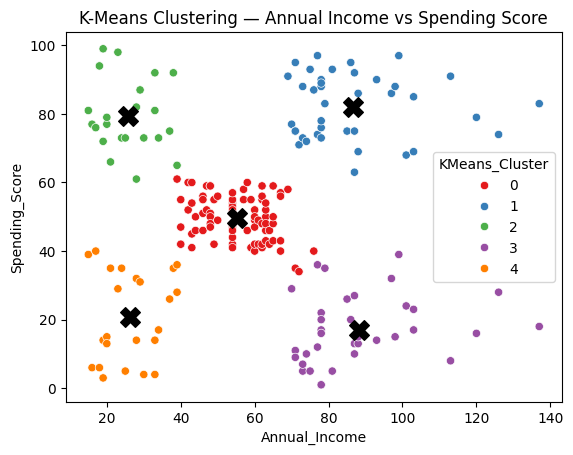

In [48]:
sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='KMeans_Cluster',data=df,palette='Set1')

centroids_scaled = kmeans.cluster_centers_

centroids_full = np.zeros((5, 3))
centroids_full[:, 1:] = centroids_scaled

centroids_raw = scaler.inverse_transform(centroids_full)[:, 1:]

plt.scatter(centroids_raw[:, 0],centroids_raw[:, 1],c='black',marker='X',s=200)

plt.title('K-Means Clustering — Annual Income vs Spending Score')
plt.show()

## Cluster profile table

In [49]:
cluster_summary = df.groupby('KMeans_Cluster')[['Age','Annual_Income','Spending_Score']].mean()

cluster_summary.style.format({
    'Age': '{:.1f}',
    'Annual_Income': '{:.1f}',
    'Spending_Score': '{:.1f}'
}).background_gradient(cmap='Blues')

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.7,55.3,49.5
1,32.7,86.5,82.1
2,25.3,25.7,79.4
3,41.1,88.2,17.1
4,45.2,26.3,20.9


### Customer Segment Interpretation

#### Cluster 0 — Medium Income, Medium Spenders
- These customers have moderate annual income and moderate spending scores.
- They represent a relatively balanced customer segment.
- Business implication: The mall can use regular promotion and personalized offers to encourage these customers to increase their spending.

#### Cluster 1 — High Income, High Spenders
- These customers have high annual income and high spending scores.
- They represent customers with strong purchasing power and high engagement with the mall.
- Business implication: The mall can target them with premium products and exclusive offers.

#### Cluster 2 — Low Income, High Spenders
- These customers have relatively lower income but high spending scores.
- They show strong spending behaviour despite having lower income.
- Business implication: Discounts, attractive deals and seasonal promotions may help retain these customers and encourage repeat visits.

#### Cluster 3 — High Income, Low Spenders
- These customers have high annual income but relatively low spending scores.
- They have purchasing capacity but are not currently spending heavily.
- Business implication: The mall could use personalised marketing and premium experiences to encourage greater engagement and spending.

#### Cluster 4 — Low Income, Low Spenders
- These customers have relatively lower income and lower spending scores.
- Their spending activity is comparatively limited.
- Business implication: The mall can focus on affordable products and discounts to attract and retain this segment.

# Task 4 : Agglomerative Hierarchical Clustering

## Dendrogram

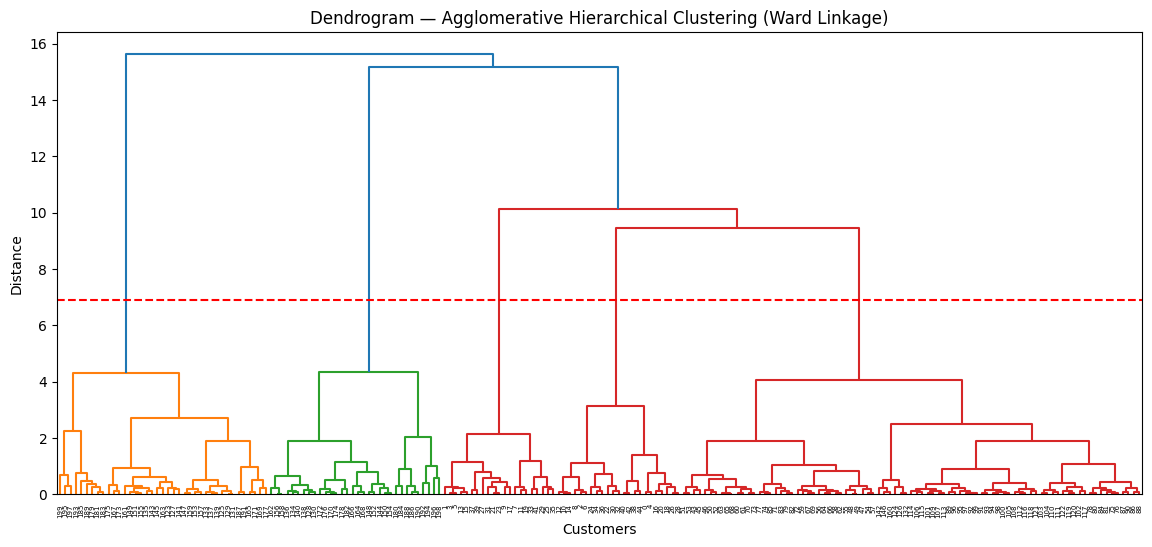

In [50]:
Z = linkage(df_2f, method='ward')

distances = Z[:, 2]
gaps = distances[1:] - distances[:-1]

i = gaps.argmax()

cut_height = (distances[i] + distances[i + 1]) / 2

plt.figure(figsize=(14, 6))

dendrogram(Z)

plt.axhline(
    y=cut_height,
    color='red',
    linestyle='--'
)

plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

### Hierarchical Clustering - Dendrogram

- Ward linkage joins clusters in a way that keeps the resulting clusters as compact as possible by minimizing the increase in within-cluster variance.
- The dendrogram shows how individual customers are gradually merged into larger groups.
- The height of a merge represents the distance between the groups being joined.
- A large vertical gap between two merge levels indicates that relatively distant groups are being merged.
- The horizontal dashed line represents a possible cut-off point for the dendrogram.
- The number of branches crossed by this horizontal line gives an estimate of the number of clusters.
- Therefore, the largest vertical gap can be used as a guide for selecting the number of clusters.

## Fit Agglomerative model

In [51]:
hier = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

df['Hier_Cluster'] = hier.fit_predict(df_2f)


In [52]:
print(df['Hier_Cluster'].value_counts())

Hier_Cluster
2    85
1    39
0    32
4    23
3    21
Name: count, dtype: int64


## Visualise Hierarchical clusters

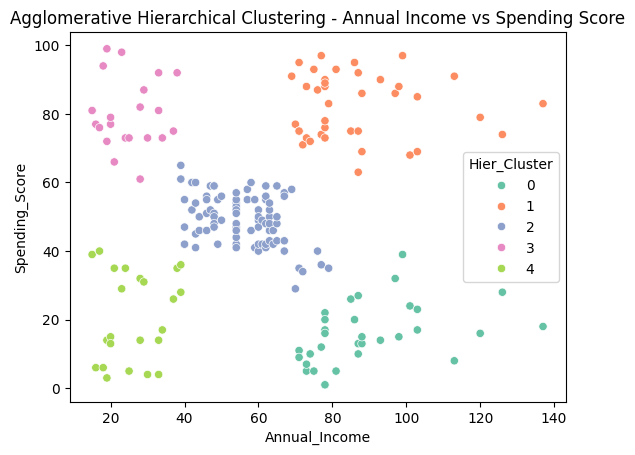

In [53]:
sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='Hier_Cluster',data=df,palette='Set2')

plt.title('Agglomerative Hierarchical Clustering - Annual Income vs Spending Score')
plt.show()

## Compare with K-Means

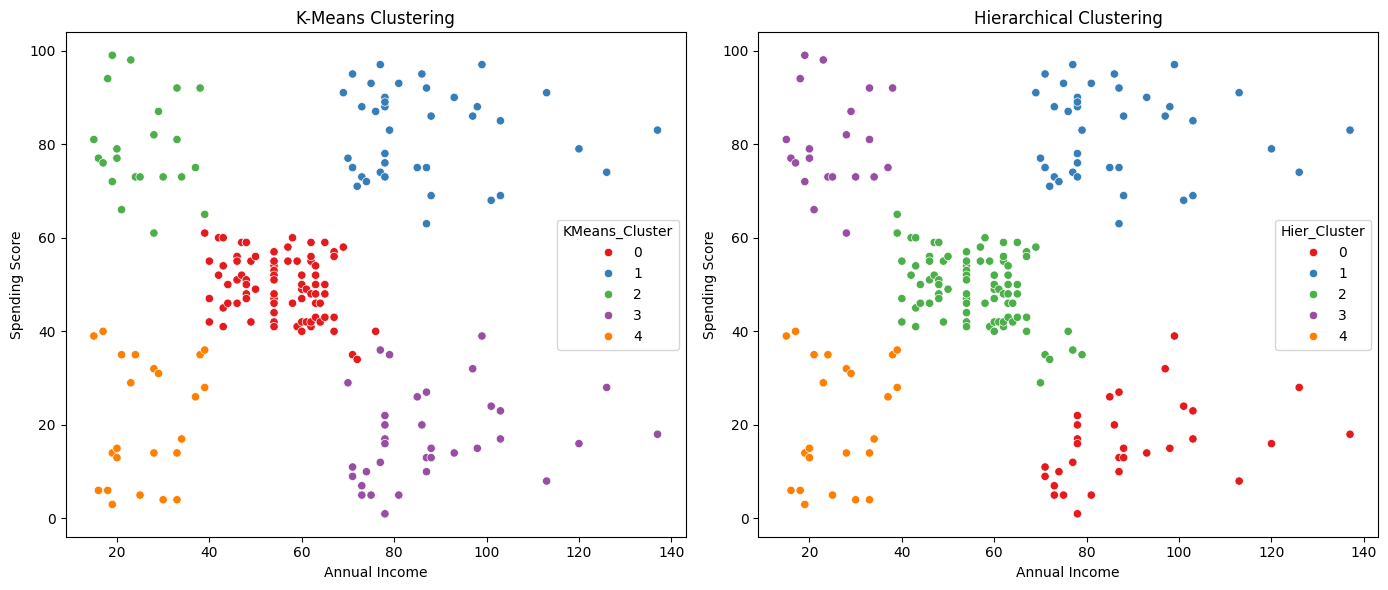

In [54]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='KMeans_Cluster',data=df,palette='Set1')

plt.title('K-Means Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')


plt.subplot(1, 2, 2)

sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='Hier_Cluster',data=df,palette='Set1')

plt.title('Hierarchical Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.tight_layout()
plt.show()

### K-Means vs Hierarchical Clustering

- Both algorithms identify the main customer segments quite similarly. The low-income/low-spending, low-income/high-spending, high-income/high-spending, and high-income/low-spending groups are clearly visible in both plots.
- The main differences occur for customers located near the boundaries between groups, especially around the middle-income and medium-spending region.
- In the K-Means result, the central group appears more compact because K-Means assigns each customer to the nearest centroid (cluster center).
- In the Hierarchical result, some boundary customers are grouped differently because Hierarchical Clustering builds clusters by progressively joining nearby customers or groups.
- K-Means is centroid-based: it calculates a center for each cluster and assigns customers according to their distance from these centers.
- Hierarchical Clustering is connectivity-based: it starts with individual customers and progressively connects nearby customers or groups using the Ward linkage method.
- Therefore, customers close to the boundary can receive different assignments because the two algorithms use different ways of defining a cluster.
- The cluster numbers should not be compared directly between the two plots because Cluster 0 in K-Means does not necessarily represent the same group as Cluster 0 in Hierarchical Clustering.

## Cluster profile table

In [55]:
hier_summary = df.groupby('Hier_Cluster')[['Age','Annual_Income','Spending_Score']].mean()

hier_summary.style.format({
    'Age': '{:.1f}',
    'Annual_Income': '{:.1f}',
    'Spending_Score': '{:.1f}'
}).background_gradient(cmap='Blues')

,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.0,89.4,15.6
1,32.7,86.5,82.1
2,42.5,55.8,49.1
3,25.3,25.1,80.0
4,45.2,26.3,20.9


### Comparison of K-Means and Hierarchical Cluster Profiles

- The mean values from Hierarchical Clustering show customer segments that are broadly similar to the segments identified by K-Means.
- Both methods identify groups with low income/low spending, low income/high spending, high income/high spending, and high income/low spending characteristics.
- The main differences occur in the middle-income and medium-spending region, where some customers are assigned to different clusters by the two methods.
- The cluster numbers are different labels and should not be compared directly. The segments should be compared using their mean Age, Annual Income, and Spending Score.
- Overall, the segment definitions are largely consistent, although some boundary customers are assigned differently because K-Means uses centroids while Hierarchical Clustering uses connectivity between observations.

# Task 5 : DBSCAN Clustering

## Parameter tuning - epsilon

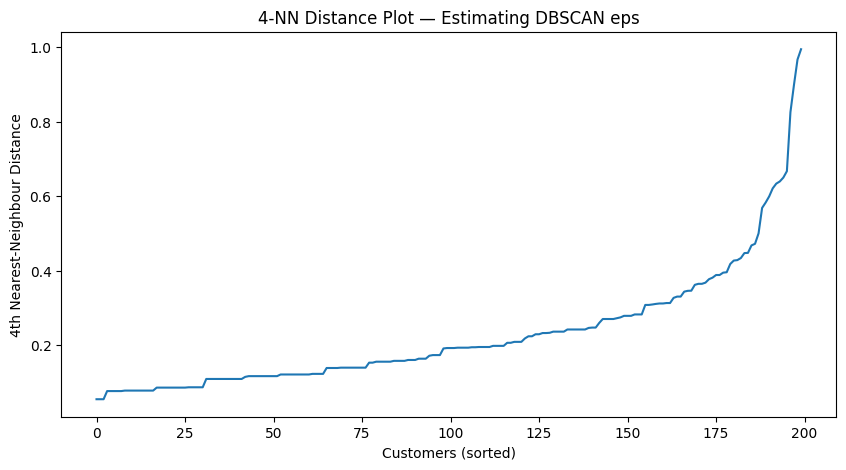

In [56]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors.fit(df_2f)

distances, indices = neighbors.kneighbors(df_2f)

k_distances = distances[:, 3]

k_distances = sorted(k_distances)

plt.figure(figsize=(10, 5))
plt.plot(k_distances)

plt.xlabel('Customers (sorted)')
plt.ylabel('4th Nearest-Neighbour Distance')
plt.title('4-NN Distance Plot — Estimating DBSCAN eps')

plt.show()

## Grid search eps & min_samples

In [57]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(df_2f)
        
        noise = sum(labels == -1)
    
        cluster_labels = set(labels)
        cluster_labels.discard(-1)
        n_clusters = len(cluster_labels)

        non_noise = labels != -1

        if n_clusters >= 2:
            score = silhouette_score(
                df_2f[non_noise],
                labels[non_noise]
            )
        else:
            score = np.nan

        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'Clusters': n_clusters,
            'Noise_Points': noise,
            'Silhouette_Score': score
        })

results_df = pd.DataFrame(results)

results_df

,eps,min_samples,Clusters,Noise_Points,Silhouette_Score
0,0.2,3,13,44,0.469713
1,0.2,4,5,73,0.617282
2,0.2,5,7,77,0.585613
3,0.2,6,4,95,0.613836
4,0.3,3,9,14,0.472040
5,0.3,4,8,23,0.519746
6,0.3,5,7,35,0.524328
7,0.3,6,6,48,0.530244
8,0.4,3,4,10,0.395381
9,0.4,4,3,14,0.457570


In [58]:
results_df.sort_values(
    'Silhouette_Score',
    ascending=False
)

,eps,min_samples,Clusters,Noise_Points,Silhouette_Score
1,0.2,4,5,73,0.617282
3,0.2,6,4,95,0.613836
2,0.2,5,7,77,0.585613
7,0.3,6,6,48,0.530244
6,0.3,5,7,35,0.524328
5,0.3,4,8,23,0.519746
11,0.4,6,4,19,0.490015
10,0.4,5,4,15,0.478059
4,0.3,3,9,14,0.472040
0,0.2,3,13,44,0.469713


### DBSCAN Parameter Comparison & Selection

- DBSCAN was tested using eps values of 0.2, 0.3, 0.4, 0.5, and 0.6 and min_samples values of 3, 4, 5, and 6.
- For each combination, the number of clusters, number of noise points, and silhouette score were recorded.
- Noise points were identified using the DBSCAN label -1 and were excluded when calculating the silhouette score.
- A higher silhouette score indicates better separation between the identified clusters, while a lower number of noise points indicates that more customers were successfully assigned to clusters.
- The combination eps=0.2 and min_samples=4 produced the highest silhouette score (0.617), but it classified 73 customers as noise.
- A very large number of noise points makes this configuration less useful for customer segmentation.
- The combination eps=0.3 and min_samples=5 produced 5 clusters with 35 noise points and a silhouette score of approximately 0.524.
- This provides a better balance between cluster separation and the number of customers successfully assigned to clusters.
- Therefore, eps=0.3 and min_samples=5 are selected for the final DBSCAN model.


## Fit final DBSCAN model

In [59]:
dbscan = DBSCAN(eps=0.3,min_samples=5)

df['DBSCAN_Cluster'] = dbscan.fit_predict(df_2f)
print(df[['Annual_Income', 'Spending_Score', 'DBSCAN_Cluster']].head())

   Annual_Income  Spending_Score  DBSCAN_Cluster
0             15              39               2
1             15              81               0
2             16               6               1
3             16              77               0
4             17              40               2


## Visualise DBSCAN clusters

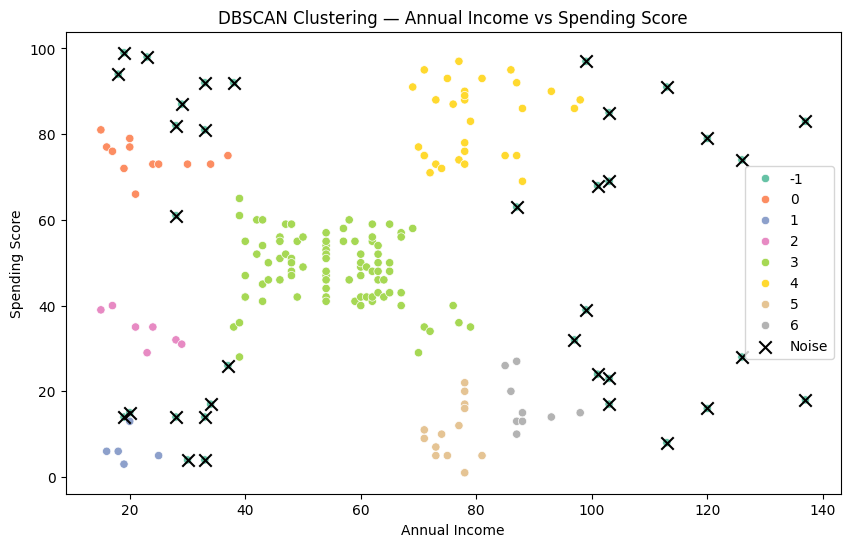

In [60]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='DBSCAN_Cluster',data=df,palette='Set2')

noise = df[df['DBSCAN_Cluster'] == -1]

plt.scatter(noise['Annual_Income'],noise['Spending_Score'],color='black',marker='x',s=80,label='Noise')

plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

## DBSCAN vs K-Means - shape detection

### DBSCAN Parameters and Noise Points

- eps controls the maximum distance between two points for them to be considered neighbors.
- A smaller eps creates smaller and denser neighborhoods, while a larger eps allows points that are farther apart to be grouped together.
- min_samples controls the minimum number of nearby points required for a point to be considered part of a dense region.
- If a point does not have enough nearby points within the eps distance, DBSCAN may classify it as noise.
- DBSCAN represents noise points using the label -1.
- In the scatter plot, noise points are shown in black with an X marker.
- These noise points are observations that are too far from any sufficiently dense region to belong to a cluster.

### DBSCAN vs K-Means

- On this dataset, the three algorithms do not necessarily agree on the exact number of customer segments. K-Means and Hierarchical Clustering were configured with 5 clusters, while DBSCAN determines its cluster count from the density of the data.
- Even when the exact number of clusters differs, the main customer patterns are broadly similar across the methods.
- The most stable segments are:
  - Low income + low spending
  - Low income + high spending
  - High income + high spending
  - High income + low spending
- The middle-income / medium-spending group is less stable because customers in this region lie closer to the boundaries between clusters and may be assigned differently by different algorithms.
- Therefore, the algorithms agree more strongly on the major customer segments and their characteristics than on the exact cluster labels or number of clusters.

# Task 6: Algorithm Comparison & Business Insights

## Three-panel comparison figure

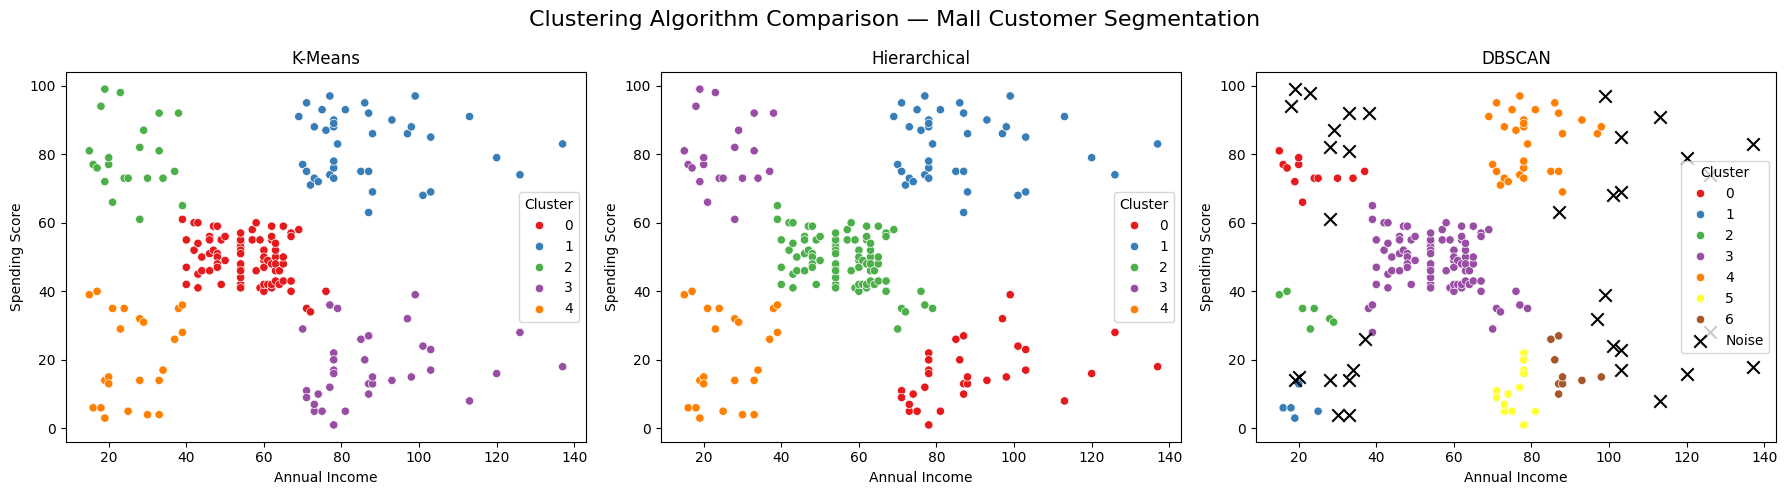

In [61]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)

sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='KMeans_Cluster',data=df,palette='Set1')

plt.title('K-Means')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')


plt.subplot(1, 3, 2)

sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='Hier_Cluster',data=df,palette='Set1')

plt.title('Hierarchical')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')


plt.subplot(1, 3, 3)

sns.scatterplot(x='Annual_Income',y='Spending_Score',hue='DBSCAN_Cluster',data=df[df['DBSCAN_Cluster'] != -1],palette='Set1')

noise = df[df['DBSCAN_Cluster'] == -1]

plt.scatter(noise['Annual_Income'],noise['Spending_Score'],color='black',marker='x',s=80,label='Noise')

plt.title('DBSCAN')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')


plt.suptitle('Clustering Algorithm Comparison — Mall Customer Segmentation',fontsize=16)

plt.tight_layout()
plt.show()

## Metrics summary table

In [62]:
kmeans_silhouette = silhouette_score(df_2f,df['KMeans_Cluster'])

hier_silhouette = silhouette_score(df_2f,df['Hier_Cluster'])

dbscan_mask = df['DBSCAN_Cluster'] != -1

dbscan_data = df_2f[dbscan_mask]
dbscan_labels = df.loc[dbscan_mask, 'DBSCAN_Cluster']

dbscan_silhouette = silhouette_score(dbscan_data,dbscan_labels)

kmeans_clusters = df['KMeans_Cluster'].nunique()
hier_clusters = df['Hier_Cluster'].nunique()
dbscan_clusters = df.loc[dbscan_mask, 'DBSCAN_Cluster'].nunique()

comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'n_clusters': [kmeans_clusters,hier_clusters,dbscan_clusters],
    'Silhouette Score': [kmeans_silhouette,hier_silhouette,dbscan_silhouette]
})

comparison

,Algorithm,n_clusters,Silhouette Score
0,K-Means,5,0.554657
1,Hierarchical,5,0.553809
2,DBSCAN,7,0.524328


### Clustering Algorithm Performance Comparison

The Silhouette Score measures how well each customer fits within its assigned cluster.

- A score closer to 1 indicates that clusters are well separated and internally compact.
- A score closer to 0 indicates that clusters overlap or are close to each other.
- A negative score can indicate that some observations may be assigned to the wrong cluster.

For DBSCAN, noise points (-1) are excluded from the Silhouette Score calculation because they do not belong to any cluster.

The algorithm with the highest Silhouette Score performs best according to this metric because it produces clusters that are more compact and better separated.

Therefore, the best-performing algorithm in this comparison is K-Means.

## Business insight report

## Business Insights for Mall Management

### 1. Customer Segments Identified by K-Means

K-Means provides an easy-to-interpret segmentation of mall customers based on Annual Income and Spending Score.

#### Cluster 0 — Medium Income / Medium Spenders
- These customers have moderate income and moderate spending behaviour.
- They represent a balanced customer group with potential to increase their spending.
- Marketing Action: Offer personalized discounts and bundle deals to encourage higher purchase frequency.

#### Cluster 1 — High Income / High Spenders
- These customers have high income and already spend heavily at the mall.
- They are valuable customers with strong purchasing behaviour.
- Marketing Action: Provide loyalty rewards, VIP benefits, and exclusive premium offers.

#### Cluster 2 — Low Income / High Spenders
- These customers have relatively low income but maintain high spending levels.
- They may respond strongly to attractive products and promotions.
- Marketing Action: Use targeted promotional offers, discounts, and limited-time deals to encourage repeat purchases.

#### Cluster 3 — High Income / Low Spenders
- These customers have high income but relatively low spending.
- They have purchasing capacity but may not currently spend much at the mall.
- Marketing Action: Use personalized premium recommendations and exclusive experiences to encourage greater engagement.

#### Cluster 4 — Low Income / Low Spenders
- These customers have lower income and lower spending levels.
- Price sensitivity is likely to be more important for this group.
- Marketing Action: Provide budget-friendly promotions, value deals, and seasonal discounts.


---

### 2. Recommended Marketing Strategy

Each segment should receive a different marketing approach:


Medium Income / Medium Spend ---> Personalized discounts and bundle deals 
High Income / High Spend ---> Loyalty rewards and VIP benefits 
Low Income / High Spend ---> Promotions and limited-time discounts 
High Income / Low Spend ---> Premium recommendations and exclusive experiences 
Low Income / Low Spend ---> Budget promotions and value deals 

---

### 3. Recommended Algorithm for Deployment

For this mall customer segmentation task, K-Means is the most interpretable choice for deployment.

- K-Means: Recommended when management needs clear and easily understandable customer segments. The cluster centroids make it straightforward to describe customers using income and spending behaviour.
- DBSCAN Useful when the shape and structure of the clusters are unknown and when identifying low-density customers or outliers is important.
- Hierarchical Clustering: Useful when management wants to present a dendrogram showing how customer groups progressively merge into larger groups.

For this particular business application, K-Means provides a straightforward way to translate the clustering results into customer segments and targeted marketing actions.